Name: Muhtasim Haque Nahian

Labpartner(s): Haoxin Ni

In [2]:
#import statements go here
import matplotlib.pyplot as plt
import numpy as np

# Class 6.1

Today we will start with fiunction sharing and do more matplotlib.

# Warmups 6.1

**W.1** Write a function that loops through a list of numbers and checks if they are odd or even, then returns a new list of "odd" or "even" for each element in the input list. For example:

Given the list [3,8,7] the function would return
["odd", "even", "odd"]

In [4]:
def odd_or_even(numbers):
    result = []

    for number in numbers:
        if number % 2 == 0:
            result.append("even")
        else:
            result.append("odd")

    return result

# input
numbers = list(map(int, input("Enter numbers separated by spaces: ").split()))

print(odd_or_even(numbers))

Enter numbers separated by spaces:  2 4 5 6 0


['even', 'even', 'odd', 'even', 'even']


# Lecture 6.1

### Agenda:

- Show us your functions
- Questions
- xarray package and plotting netcdf files


### Show us your functions (from Lab 5.2) - first 4 people today, the rest on Wed

### Questions

### Loading and plotting netcdf files using xarray

Most modeling data output is in the form of netcdf files, as they can store more data (in binary) using less memory. Netcdf files are great because they tell you all about what is in the file (the variables and their units) with their metadata, which is kind of like the docstring we made for our function. There are a number of command line (unix-based) utilities for dealing with netcdf files, which I am not planning to cover in this course (though I use these all the time). Hit me up if you want some tutorials on this, or if enough of you are keen I will put some unix tutorials in the schedule.

Xarray is a python package that does analysis and basic plotting of netcdf files. This is actively being developed by folks like the pangeo consortium (https://pangeo.io), which is creating a number of python utilities for big data geoscience, like dealing with massive amounts of climate model output. There are other packages that can be used for parsing netcdf files, but they are cumbersome and clunky. Trust me, xarray is the best thing since sliced bread for big data geoscience. 

Let's grab some data and start playing with it. We are going to use the HYCOM Gulf of Mexico Analysis output, which is basically weather prediction for our local ocean made by the Navy, freely available. https://www.hycom.org.

In [4]:
import xarray as xr
# make sure you also have nectdf4 installed!

### Part 1: Load in the file (always the hardest part)!

We want the HYCOM GoM reanalysis product: https://www.hycom.org/dataserver/gom/gom-reanalysis
And we are going to use the coarser resolution (1/25 degree) version for computational speed, the "HYCOM-TSIS 1/25º Gulf of Mexico Reanalysis (GOMe0.04)" version, which goes from 2024-09-01 to present.

There are two ways to get this data, we can click around and download it, or we can use the opendap link (see http://xarray.pydata.org/en/stable/io.html).

In [5]:
# here I am going to grab the hindcast they made for Jan 1 2026. 

#First let's navigate to the website and download the 2d file.

# Note I can use the download the file I got by clicking on the https server link and putting the correct path to load in:
file_path= r"E:\_MS LSU\OCS 7001 Scientific Computing\039_archv.2026_001_00_2d.nc" # you will have to change this for your computer

# now upload from the file I downloaded manually:
hycom_data = xr.open_dataset(file_path, decode_times=False)

# honestly I don't know why you need the decode_times bit with open_dataset
# I just know it doesn't work most of the time if you leave it out (kudos for anyone who figures it out!)


In [6]:
hycom_data

<xarray.Dataset> Size: 5MB
Dimensions:                (MT: 1, Latitude: 385, Longitude: 525)
Coordinates:
  * MT                     (MT) float64 8B 4.566e+04
    Date                   (MT) float64 8B ...
  * Latitude               (Latitude) float32 2kB 18.09 18.13 ... 31.93 31.96
  * Longitude              (Longitude) float32 2kB -98.0 -97.96 ... -77.04
Data variables:
    surface_e_stress       (MT, Latitude, Longitude) float32 808kB ...
    surface_n_stress       (MT, Latitude, Longitude) float32 808kB ...
    ssh                    (MT, Latitude, Longitude) float32 808kB ...
    u_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    v_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    mixed_layer_thickness  (MT, Latitude, Longitude) float32 808kB ...
Attributes:
    Conventions:  CF-1.6
    title:        HYCOM
    source:       HYCOM archive file
    experiment:   01.4
    history:      archv2ncdf2d
    comment:      p-grid

The result is an xarray dataset, which is similar to the pandas dataframes you have been using. It has dimensions, coordinates and variables. The first thing to do when you get a dataset is to figure out what is in it and explore it a bit.

In [7]:
# what is the lat spacing and domain?

hycom_data.Latitude

# looks like it goes from 18.09 N to 31.96 N and the spacing is 0.04 degrees, i.e. 1/25, so that checks
# 1 degree is about 100 km, so thats 4 km model resolution

<xarray.DataArray 'Latitude' (Latitude: 385)> Size: 2kB
array([18.091648, 18.129667, 18.167677, ..., 31.892748, 31.926704, 31.960648],
      shape=(385,), dtype=float32)
Coordinates:
  * Latitude  (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
Attributes:
    standard_name:  latitude
    units:          degrees_north
    axis:           Y

In [8]:
hycom_data.Longitude

<xarray.DataArray 'Longitude' (Longitude: 525)> Size: 2kB
array([-98.      , -97.96002 , -97.91998 , ..., -77.119995, -77.08002 ,
       -77.03998 ], shape=(525,), dtype=float32)
Coordinates:
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Attributes:
    standard_name:  longitude
    units:          degrees_east
    point_spacing:  even
    axis:           X

In [9]:
hycom_data.ssh

<xarray.DataArray 'ssh' (MT: 1, Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * MT         (MT) float64 8B 4.566e+04
    Date       (MT) float64 8B ...
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]

We will plot this in the next section

In [11]:
# alternatley, with a little help from ChatGPT I can make a nice workflow to get the file from the opendap (thredds) server

# Link to where I downloaded the data manually
# Paste the URL copied from the HYCOM data website
file_url = (
    "https://data.hycom.org/datasets/GOMe0.04/expt_03.9/data/archive/2026/"
    "039_archv.2026_001_01_2d.nc"
)

# Convert the download URL to an OPeNDAP URL
opendap_url = file_url.replace(
    "https://data.hycom.org/",
    "https://tds.hycom.org/thredds/dodsC/"
)

print(opendap_url)

# Open the remote NetCDF dataset
hycom_data2 = xr.open_dataset(
    opendap_url,
    engine="netcdf4",
    decode_times=False
)

hycom_data2

# note, this would make a great function

https://tds.hycom.org/thredds/dodsC/datasets/GOMe0.04/expt_03.9/data/archive/2026/039_archv.2026_001_01_2d.nc


<xarray.Dataset> Size: 5MB
Dimensions:                (MT: 1, Latitude: 385, Longitude: 525)
Coordinates:
  * MT                     (MT) float64 8B 4.566e+04
    Date                   (MT) float64 8B ...
  * Latitude               (Latitude) float32 2kB 18.09 18.13 ... 31.93 31.96
  * Longitude              (Longitude) float32 2kB -98.0 -97.96 ... -77.04
Data variables:
    surface_e_stress       (MT, Latitude, Longitude) float32 808kB ...
    surface_n_stress       (MT, Latitude, Longitude) float32 808kB ...
    ssh                    (MT, Latitude, Longitude) float32 808kB ...
    u_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    v_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    mixed_layer_thickness  (MT, Latitude, Longitude) float32 808kB ...
Attributes:
    Conventions:                     CF-1.6
    title:                           HYCOM
    source:                          HYCOM archive file
    experiment:                      01.4
    history:                         archv2ncdf2d
    comment:                         p-grid
    DODS_EXTRA.Unlimited_Dimension:  MT

However, what I really want is to plot SST, so I need a file with temperature, let's check out the other file type

In [12]:
# modify the file to get the 3D output file

# Paste the URL copied from the HYCOM data website
file_url = (
    "https://data.hycom.org/datasets/GOMe0.04/expt_03.9/data/archive/2026/"
    "039_archv.2026_001_01_3z.nc"
)

# Convert the download URL to an OPeNDAP URL
opendap_url = file_url.replace(
    "https://data.hycom.org/",
    "https://tds.hycom.org/thredds/dodsC/"
)

print(opendap_url)

# Open the remote NetCDF dataset
hycom_data_3D = xr.open_dataset(
    opendap_url,
    engine="netcdf4",
    decode_times=False
)

hycom_data_3D

https://tds.hycom.org/thredds/dodsC/datasets/GOMe0.04/expt_03.9/data/archive/2026/039_archv.2026_001_01_3z.nc


<xarray.Dataset> Size: 162MB
Dimensions:     (MT: 1, Depth: 40, Latitude: 385, Longitude: 525)
Coordinates:
  * MT          (MT) float64 8B 4.566e+04
    Date        (MT) float64 8B ...
  * Depth       (Depth) float32 160B 0.0 2.0 4.0 6.0 ... 3e+03 4e+03 5e+03
  * Latitude    (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude   (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Data variables:
    u           (MT, Depth, Latitude, Longitude) float32 32MB ...
    v           (MT, Depth, Latitude, Longitude) float32 32MB ...
    w_velocity  (MT, Depth, Latitude, Longitude) float32 32MB ...
    water_temp  (MT, Depth, Latitude, Longitude) float32 32MB ...
    salinity    (MT, Depth, Latitude, Longitude) float32 32MB ...
Attributes:
    Conventions:                     CF-1.0
    title:                           HYCOM
    source:                          HYCOM archive file
    experiment:                      01.4
    history:                         archv2ncdf3z
    DODS_EXTRA.Unlimited_Dimension:  MT

### Part2: Basic plotting with xarray (not publication ready!)

Note that one of the amazing things about xarray, is that it actually does not go and get the data until you call for it, so this will take a minute to upload.

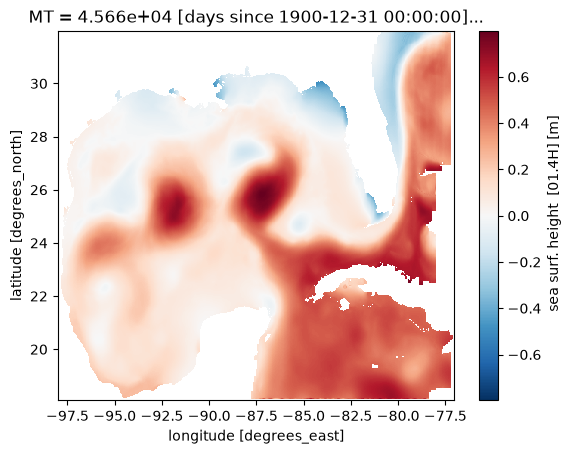

In [13]:
hycom_data.ssh.plot()

Note that xarray, like pandas, uses matplotlib for plotting, and that it figured out to use the blue to red colormap based on the type of data. Pretty cool. 

Let's plot some temperature data and see how it compares. Since temperature data is given for the whole depth, we have to select a level.

water_temp
(MT, Depth, Latitude, Longitude)

In [14]:
hycom_data_3D.water_temp[0,0,:,:]

<xarray.DataArray 'water_temp' (Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT         float64 8B 4.566e+04
    Date       float64 8B ...
    Depth      float32 4B 0.0
Attributes:
    long_name:        temp [01.4H]
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.307801 28.569424]
    _ChunkSizes:    [  1  14 193 263]

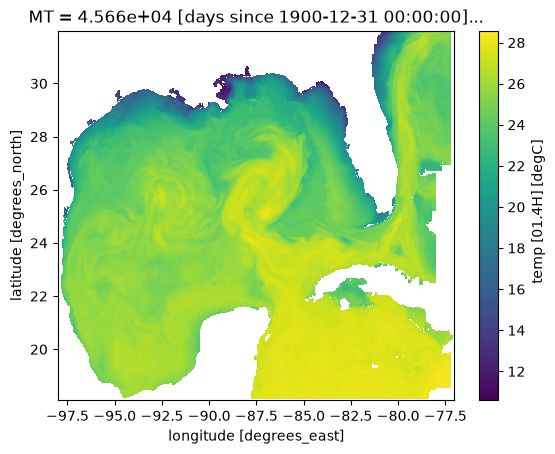

In [15]:
hycom_data_3D.water_temp[0,0,:,:].plot()

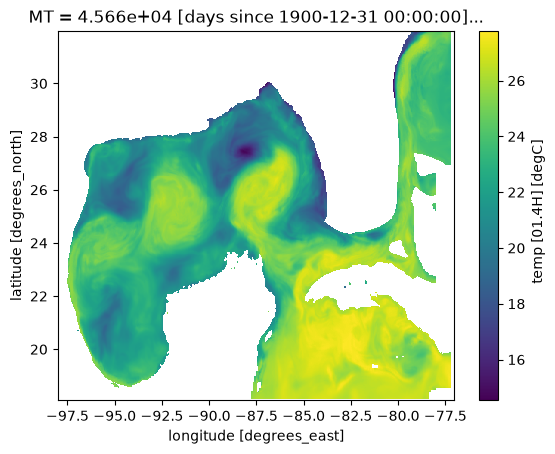

In [17]:
hycom_data_3D.water_temp[0,19,:,:].plot()

Those plots are really small. I like to change the default matplotlib preferences to make my plots bigger.

In [18]:
# change all the defaults (usually I stick this up with the import statements)

import matplotlib as mpl
mpl.rcParams['figure.figsize'] = [8.0, 5.0]
mpl.rcParams['figure.dpi'] = 500
mpl.rcParams['savefig.dpi'] = 500

mpl.rcParams['font.size'] = 12
mpl.rcParams['legend.fontsize'] = 'large'
mpl.rcParams['figure.titlesize'] = 'medium'
mpl.rcParams['lines.linewidth']= 2.0

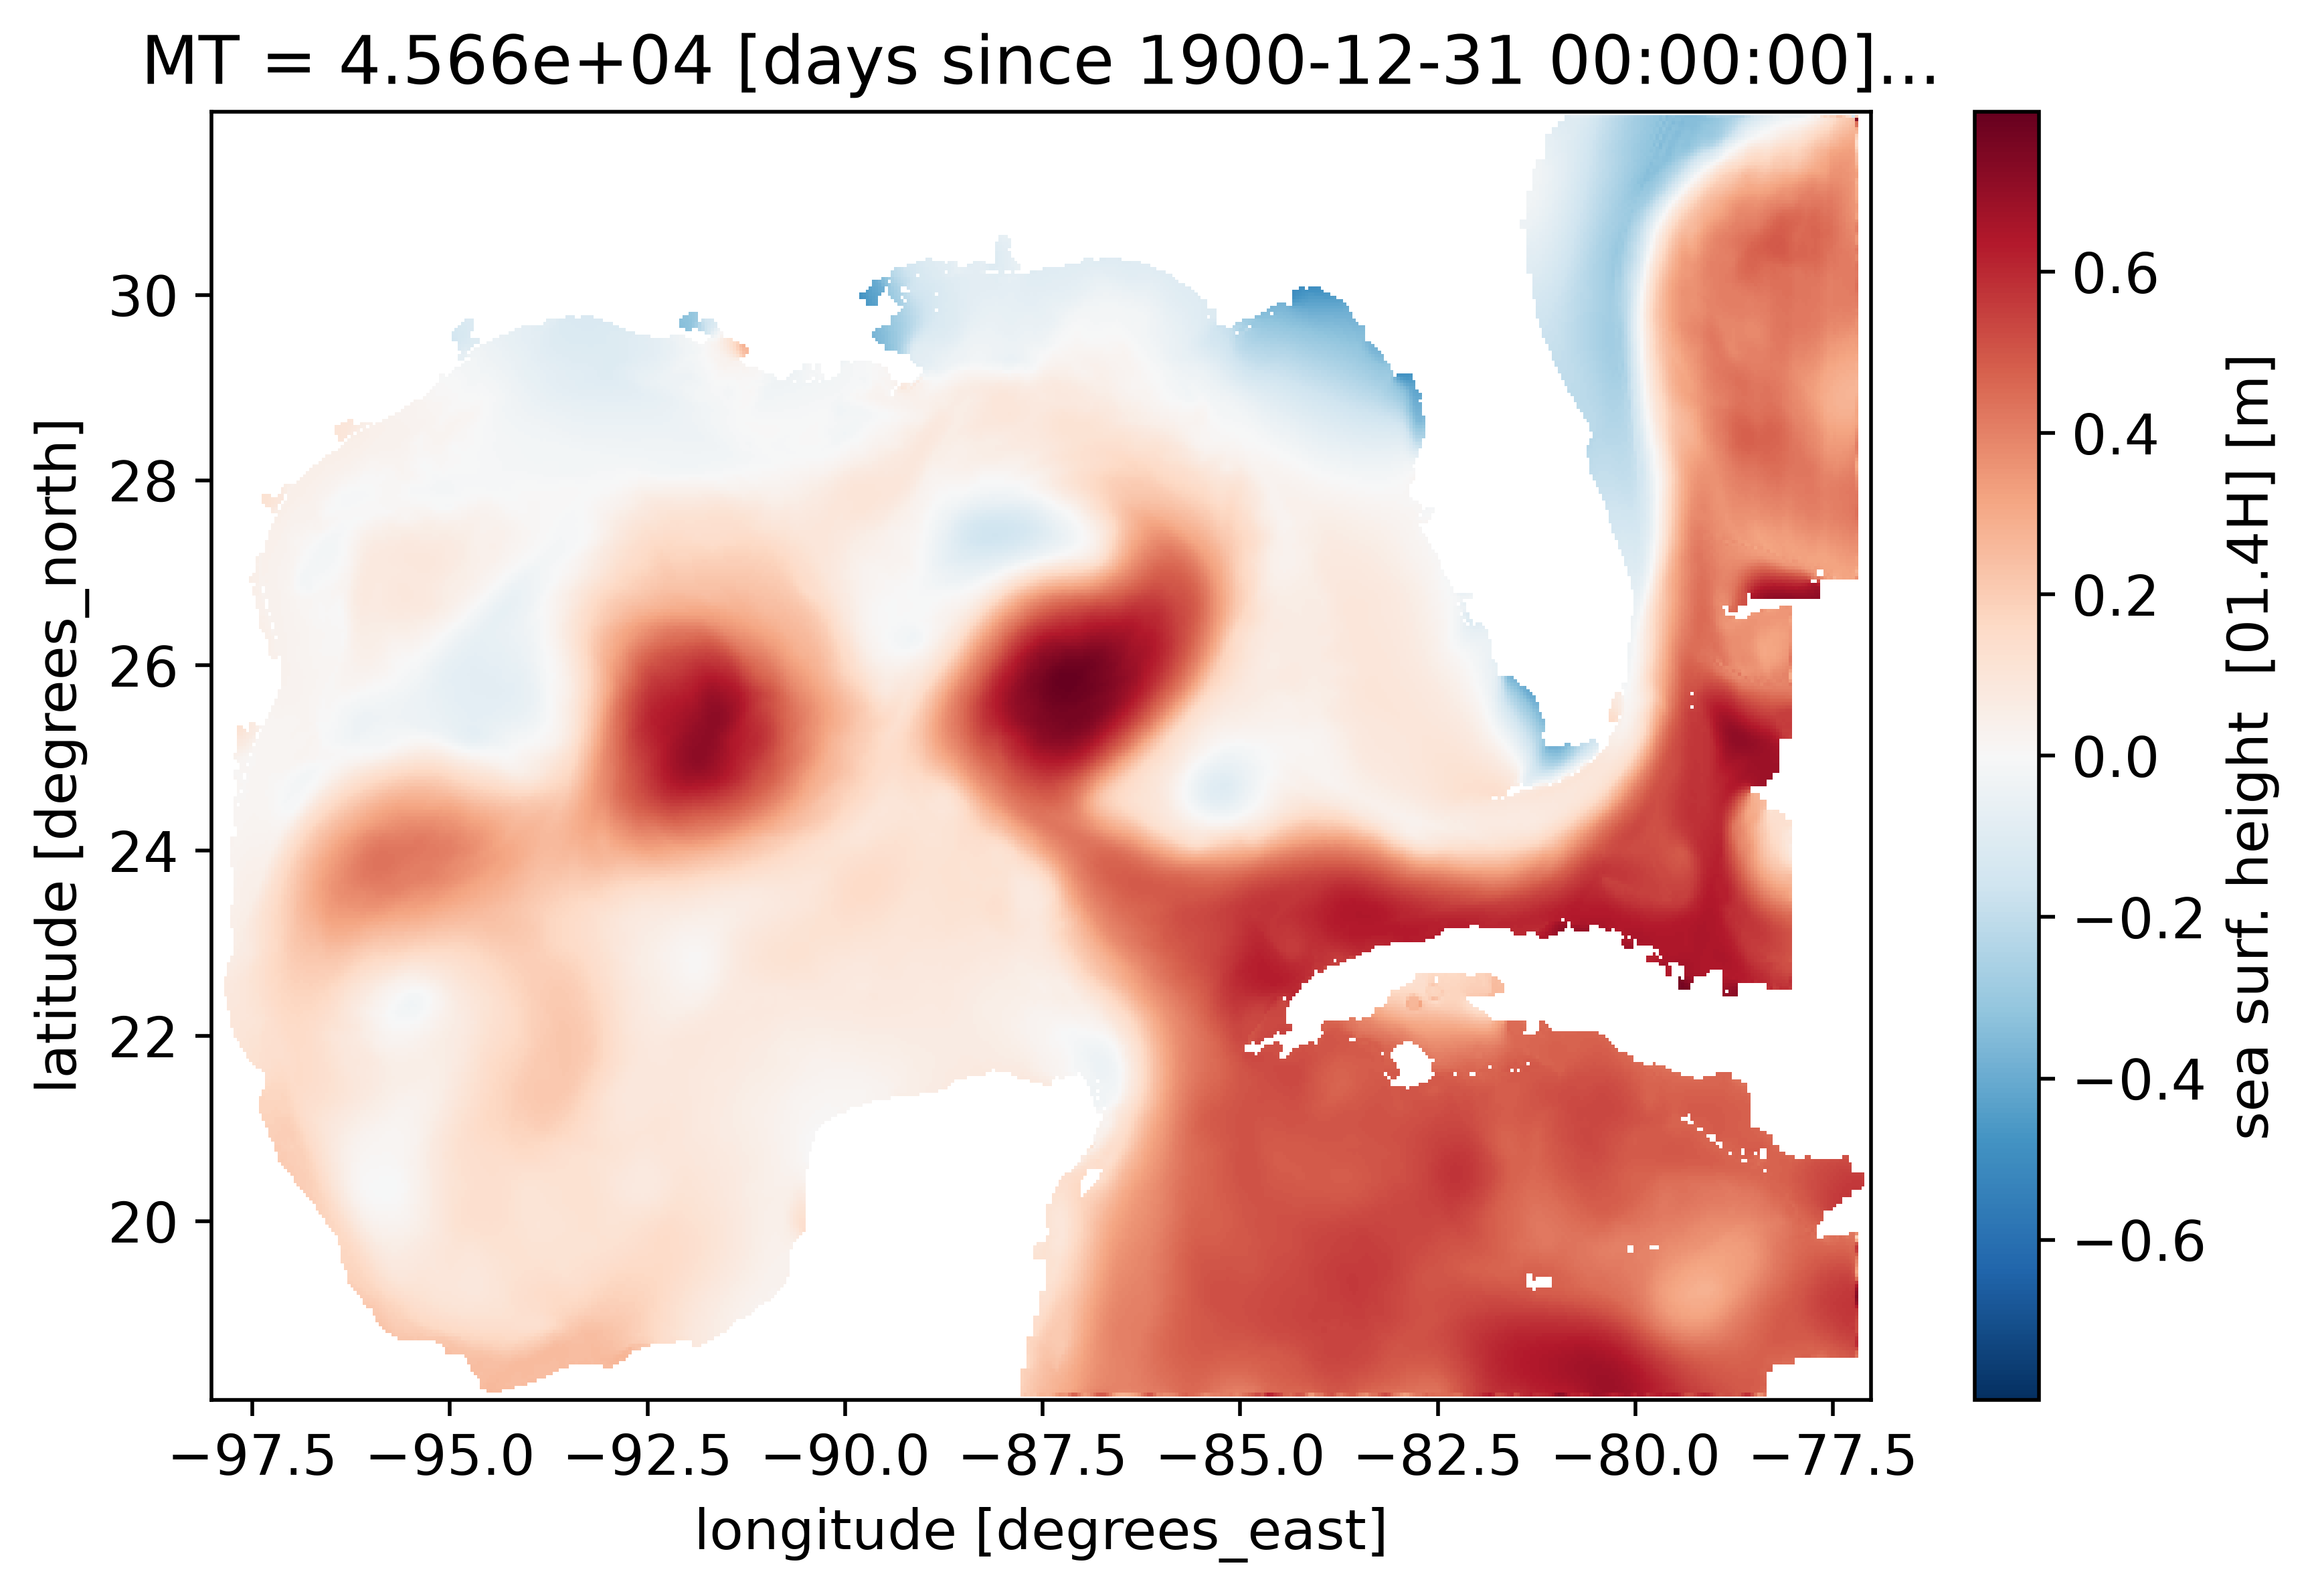

In [19]:
# now it's big and pretty.

hycom_data.ssh.plot()

Note if you know you are going to plot the same bit of data over and over again to fiddle with the plot, you can download the data you need and save it in an array to make the proccess faster.

In [20]:
SST = hycom_data_3D.water_temp[0,0,:,:]

In [21]:
type(SST)

xarray.core.dataarray.DataArray

In [22]:
SST # note it saves all the coordinates I need.

<xarray.DataArray 'water_temp' (Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT         float64 8B 4.566e+04
    Date       float64 8B ...
    Depth      float32 4B 0.0
Attributes:
    long_name:        temp [01.4H]
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.307801 28.569424]
    _ChunkSizes:    [  1  14 193 263]

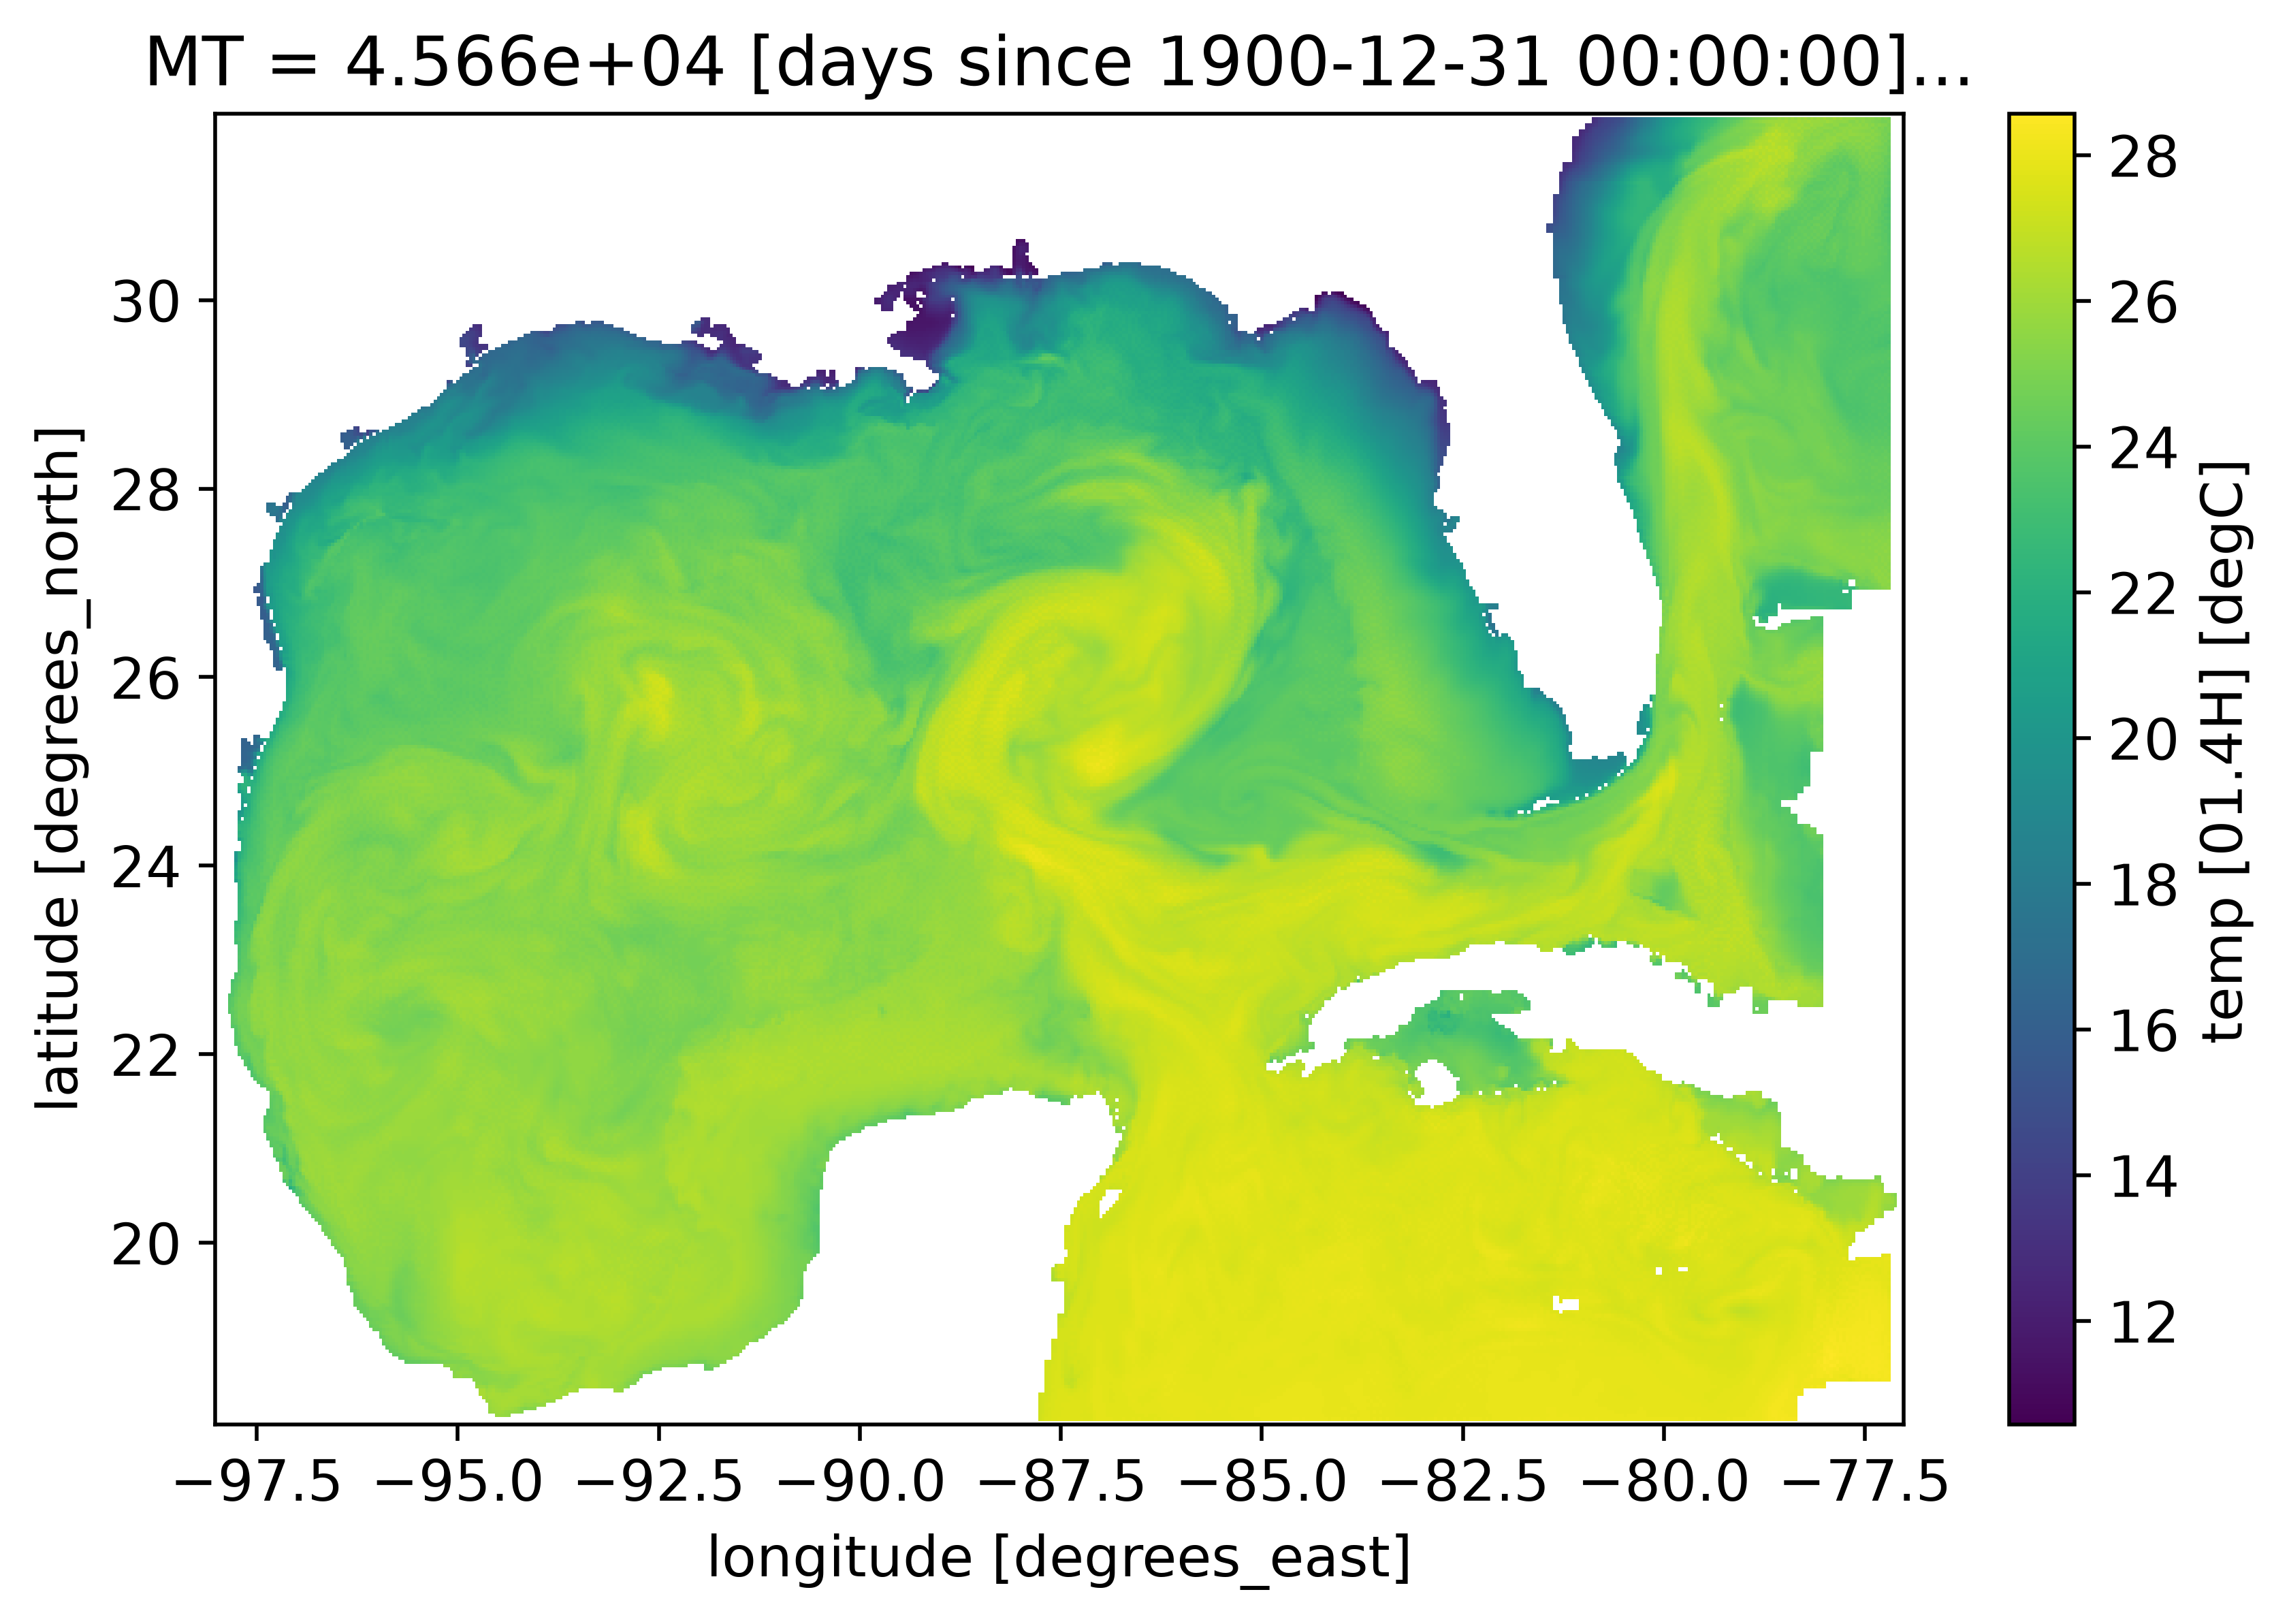

In [23]:
SST.plot()

I can also save this subset of the data to a new netcdf file locally very easily. See http://xarray.pydata.org/en/stable/io.html for more details.

In [27]:
SST.to_netcdf('SST_2001_001_01.nc') # the new netcdf file is saved in the local directory

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\ASUS\\Desktop\\OCS 7001\\SST_2001_001_01.nc'

And then I load in the new netcdf file in the same way as I did the remote data, but using the local filepath

In [28]:
sst_data = xr.open_dataset('SST_2001_001_01.nc', decode_times=False)

In [29]:
sst_data

<xarray.Dataset> Size: 812kB
Dimensions:     (Latitude: 385, Longitude: 525)
Coordinates:
  * Latitude    (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude   (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT          float64 8B ...
    Date        float64 8B ...
    Depth       float32 4B ...
Data variables:
    water_temp  (Latitude, Longitude) float32 808kB ...

# Lab 6.1

**E.0** Finish Lab 5.2 if you haven't already.

**E.1** Complete Introduction to Data Visualization with Matplotlib Chapters 1-2. Let me know if this feels like a good pace

**E.2** Make notes for yourself on progamming tecniques and commands you learned in the lecture and datacamp chapter above, including examples, comments and explainitory text. You can do this here or in a separate notebook that you link to here. Basically, you are making a cheat sheet for yourself.

See also http://xarray.pydata.org/en/stable/plotting.html for more info about plotting right from xarray (optional).

In [3]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [12]:
#data preparation for my cheatsheet
base_url = ("https://raw.githubusercontent.com/elmoallistair/""datacamp-data-analyst-with-python/master/""05_introduction-to-data-visualization-with-matplotlib/datasets/")
seattle_weather = pd.read_csv(base_url + "seattle_weather.csv")
austin_weather = pd.read_csv(base_url + "austin_weather.csv")

seattle_weather = seattle_weather[seattle_weather["STATION"] == "USW00024233"].copy()

seattle_weather = seattle_weather.sort_values("DATE")
austin_weather = austin_weather.sort_values("DATE")

months = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun", 7: "Jul", 8: "Aug",9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}

seattle_weather["MONTH"] = seattle_weather["DATE"].map(months)
austin_weather["MONTH"] = austin_weather["DATE"].map(months)

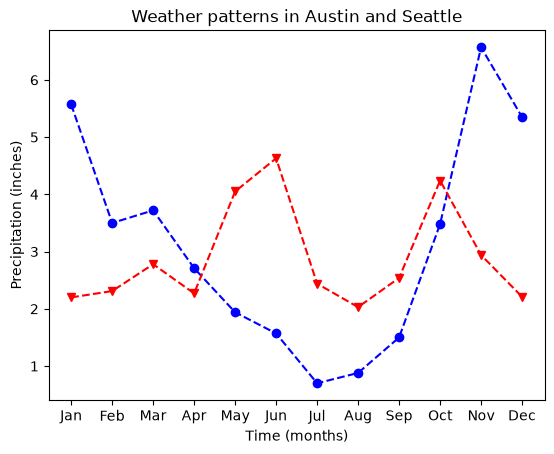

In [16]:
# ch 1

# adding data to an axes object

fig, ax = plt.subplots()

# customizing the plots
ax.plot(seattle_weather["MONTH"], seattle_weather["MLY-PRCP-NORMAL"], color="b", marker="o",linestyle="--")
ax.plot(austin_weather["MONTH"], austin_weather["MLY-PRCP-NORMAL"], color="r", marker="v",linestyle="--")

# customizing the labels and the title
ax.set_xlabel("Time (months)")
ax.set_ylabel("Precipitation (inches)")
ax.set_title("Weather patterns in Austin and Seattle")

plt.show()

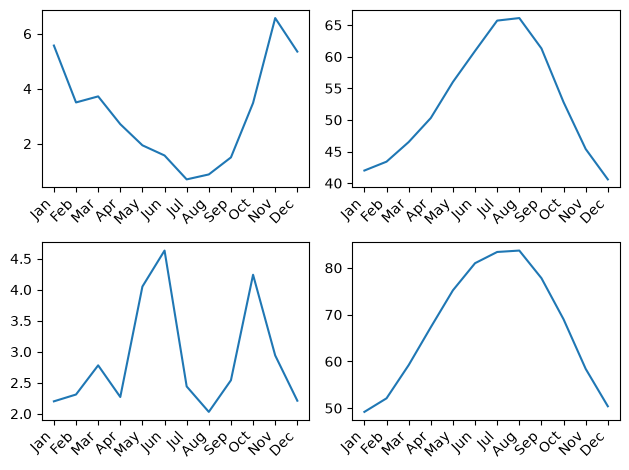

In [33]:
# plotting several datasets side-by-side

# defining an array of subplots with 2 rows and 2 columns
fig, ax = plt.subplots(2, 2)

ax[0, 0].plot(seattle_weather["MONTH"], seattle_weather["MLY-PRCP-NORMAL"])
ax[0, 1].plot(seattle_weather["MONTH"], seattle_weather["MLY-TAVG-NORMAL"])
ax[1,0].plot(austin_weather["MONTH"], austin_weather["MLY-PRCP-NORMAL"])
ax[1,1].plot(austin_weather["MONTH"], austin_weather["MLY-TAVG-NORMAL"])

for a in ax.flat: plt.setp(a.get_xticklabels(), rotation=45, ha="right")     # rotated month labels for readability
plt.tight_layout()

plt.show()

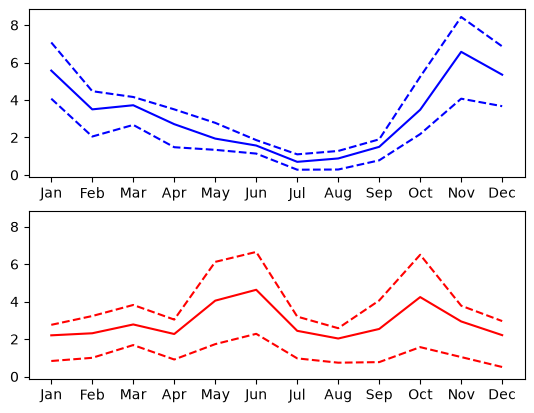

In [34]:
#plotting small multiples with shared y axis

fig, ax = plt.subplots(2, 1, sharey=True)

ax[0].plot(seattle_weather["MONTH"], seattle_weather["MLY-PRCP-NORMAL"], color="b", linestyle="-")
ax[0].plot(seattle_weather["MONTH"], seattle_weather["MLY-PRCP-25PCTL"], color="b", linestyle="--")
ax[0].plot(seattle_weather["MONTH"], seattle_weather["MLY-PRCP-75PCTL"], color="b", linestyle="--")

ax[1].plot(austin_weather["MONTH"], austin_weather["MLY-PRCP-NORMAL"], color="r", linestyle="-")
ax[1].plot(austin_weather["MONTH"], austin_weather["MLY-PRCP-25PCTL"], color="r", linestyle="--")
ax[1].plot(austin_weather["MONTH"], austin_weather["MLY-PRCP-75PCTL"], color="r", linestyle="--")

plt.show()

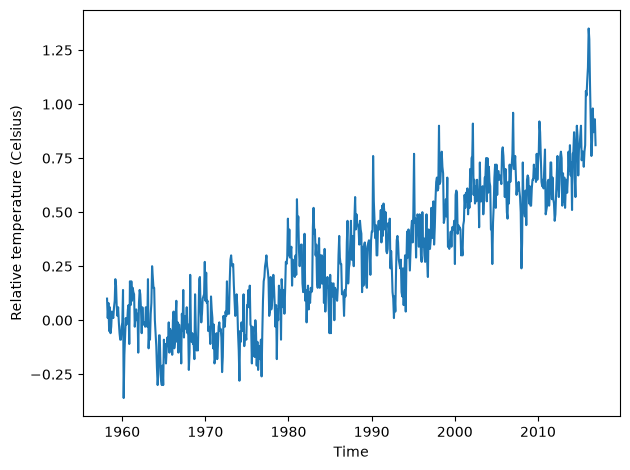

In [40]:
# ch 2

# plotting time series by storing the date's column as index, so that we can create subsets from this huge dataset by calling the index only

# data
url = ("https://raw.githubusercontent.com/goodboychan/""goodboychan.github.io/master/_notebooks/dataset/climate_change.csv")
climate_change = pd.read_csv(url, parse_dates=["date"], index_col="date")            # parse_dates = [] converted date text into actual dates

fig, ax = plt.subplots()

ax.plot(climate_change.index, climate_change["relative_temp"])

ax.set_xlabel("Time")
ax.set_ylabel("Relative temperature (Celsius)")

plt.tight_layout()
plt.show()

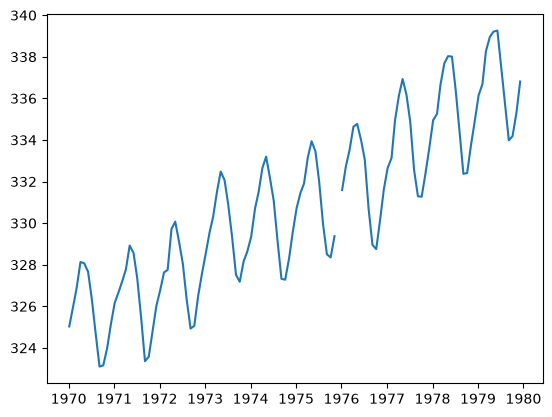

In [44]:
# using a time index to zoom in

fig, ax = plt.subplots()

seventies = climate_change["1970-01-01":"1979-12-31"]

ax.plot(seventies.index, seventies["co2"])

plt.show()

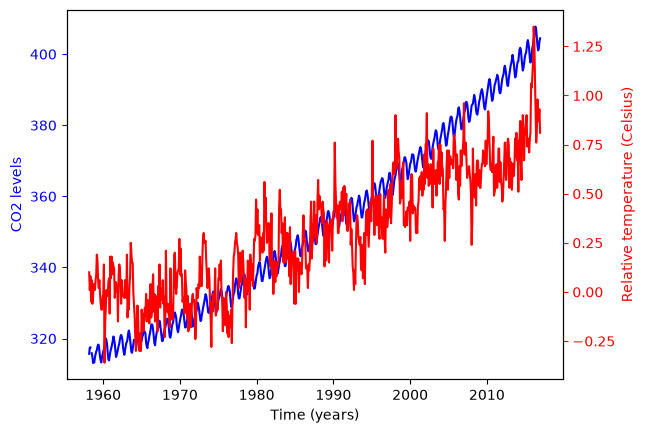

In [67]:
# plotting two variables ( plotting two y-axis against the same x-axis)

fig, ax = plt.subplots()

ax.plot(climate_change.index, climate_change["co2"], color="b")
ax.set_ylabel("CO2 levels", color="b")
ax.tick_params(axis="y", colors="b")

ax2 = ax.twinx()                # created a twin Axes that shares the x-axis

ax2.plot(climate_change.index, climate_change["relative_temp"], color="r")
ax2.set_ylabel("Relative temperature (Celsius)", color="r")
ax2.tick_params(axis="y", colors="r")

ax.set_xlabel("Time (years)")

plt.show()

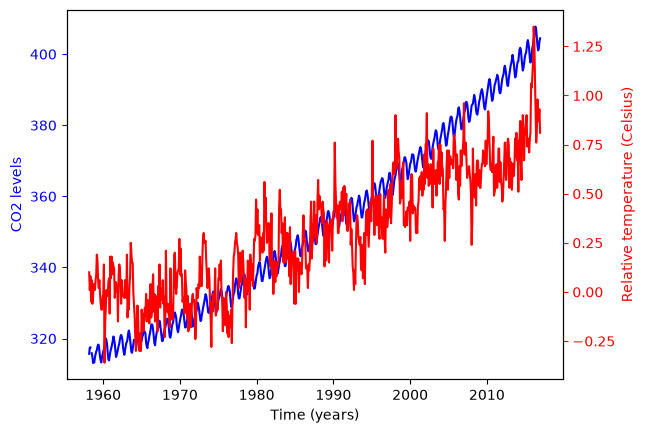

In [71]:
# same plot by defining a plot_timeseries() function

def plot_timeseries(axes, x, y, color, xlabel, ylabel):
  axes.plot(x, y, color=color)
  axes.set_xlabel(xlabel)
  axes.set_ylabel(ylabel, color=color)
  axes.tick_params('y', colors=color)
    
fig, ax = plt.subplots()

plot_timeseries(ax,climate_change.index, climate_change["co2"], "blue", "Time (years)", "CO2 levels")

ax2 = ax.twinx()

plot_timeseries(ax2,climate_change.index, climate_change["relative_temp"], "red", "Time (years)", "Relative temperature (Celsius)")   

plt.show()

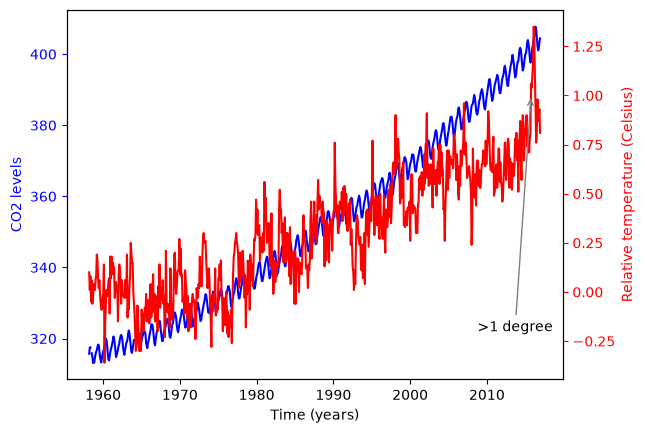

In [73]:
# using ax.annotate() to annotate

def plot_timeseries(axes, x, y, color, xlabel, ylabel):
  axes.plot(x, y, color=color)
  axes.set_xlabel(xlabel)
  axes.set_ylabel(ylabel, color=color)
  axes.tick_params('y', colors=color)
    
fig, ax = plt.subplots()

plot_timeseries(ax,climate_change.index, climate_change["co2"], "blue", "Time (years)", "CO2 levels")

ax2 = ax.twinx()

plot_timeseries(ax2,climate_change.index, climate_change["relative_temp"], "red", "Time (years)", "Relative temperature (Celsius)")   

# annotating the date at which temp exceeded 1 degree
ax2.annotate(">1 degree", xy=(pd.Timestamp("2015-10-06"), 1),xytext=(pd.Timestamp("2008-10-06"), -0.2), arrowprops={"arrowstyle": "->", "color": "gray"})

plt.show()

In [77]:
# xarray plotting

# data
airtemps = xr.tutorial.open_dataset("air_temperature")
airtemps

<xarray.Dataset> Size: 31MB
Dimensions:  (time: 2920, lat: 25, lon: 53)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Data variables:
    air      (time, lat, lon) float64 31MB ...
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

In [98]:
# Convert to celsius
air = airtemps.air - 273.15

# copy attributes to get figure labels and change Kelvin to Celsius
air.attrs = airtemps.air.attrs
air.attrs["units"] = "deg C"

display(air.attrs)

{'long_name': '4xDaily Air temperature at sigma level 995',
 'units': 'deg C',
 'precision': np.int16(2),
 'GRIB_id': np.int16(11),
 'GRIB_name': 'TMP',
 'var_desc': 'Air temperature',
 'dataset': 'NMC Reanalysis',
 'level_desc': 'Surface',
 'statistic': 'Individual Obs',
 'parent_stat': 'Other',
 'actual_range': array([185.16, 322.1 ], dtype=float32)}

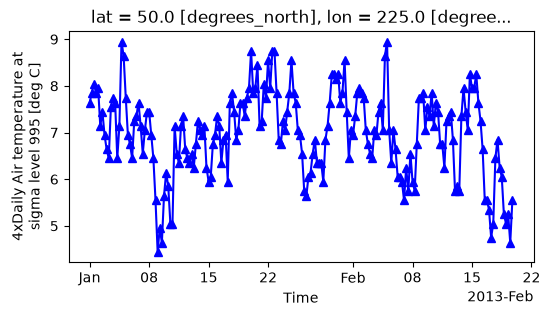

In [100]:
# selecting one grid location (lat, long) and plotting first 200 time steps, w/ H:W = 3:2

air1d = air.isel(lat=10, lon=10)
air1d[:200].plot.line("b-^", aspect=2, size=3)

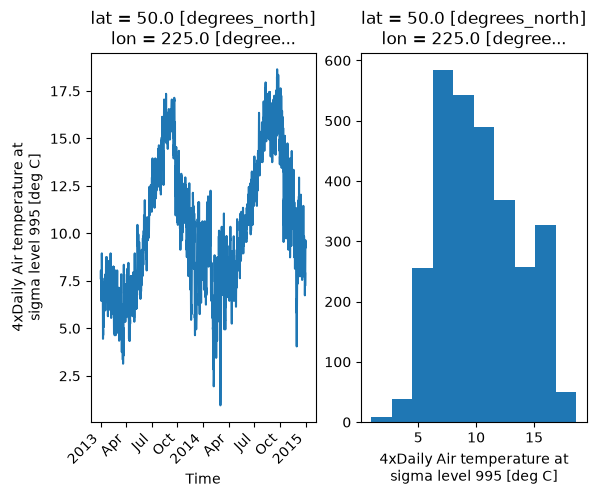

In [106]:
# side-by-side plotting

fig, axs = plt.subplots(ncols=2)

air1d.plot(ax=axs[0])
air1d.plot.hist(ax=axs[1]);


plt.setp(axs[0].get_xticklabels(), rotation=45, ha="right")      # rotated month labels for readability

for ax in axs:         
    title = ax.get_title()
    ax.set_title(title.replace(", lon", "\nlon"))                # used linebreaks of the titles for readability

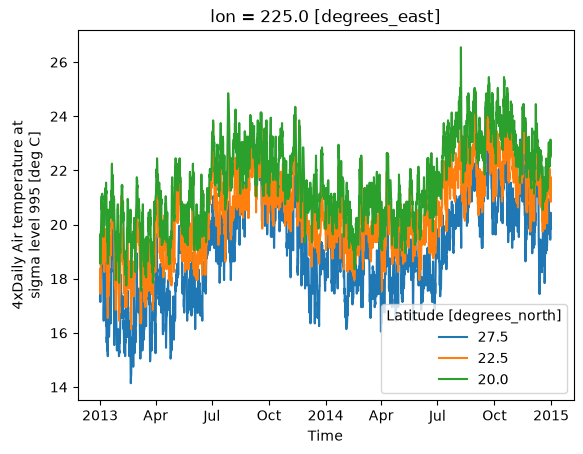

In [107]:
# plotting multiple lines of the same type of variable

air.isel(lon=10, lat=[19, 21, 22]).plot.line(x="time")

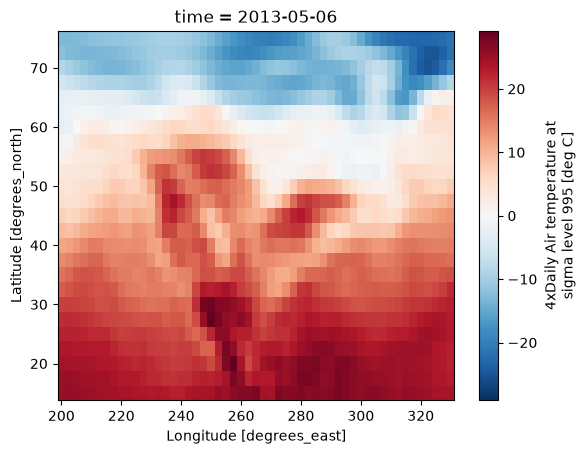

In [109]:
# 2D plotting

air2d = air.isel(time=500)
air2d.plot();

**E.3** Using the lecture as a guide, save the sea surface temperature at ~100 m depth on your birthday in 2019 as a new, local netcdf file. You don't have to submit the file, just the code here.

In [8]:
# since hycom filenames include the day of the year, i will first calculate the day number for my birthday in 2019

birthday = pd.Timestamp("2019-05-17")
day_number = birthday.dayofyear

print(day_number)

137


In [18]:

file_url = ("https://tds.hycom.org/thredds/dodsC/datasets/GOMb0.04/reanalysis/data/2019/031_archv.2019_137_00_3z.nc")
hycom_bday = xr.open_dataset(file_url, engine="netcdf4", decode_times=False)

hycom_bday

<xarray.Dataset> Size: 162MB
Dimensions:     (MT: 1, Depth: 40, Latitude: 385, Longitude: 525)
Coordinates:
  * MT          (MT) float64 8B 4.324e+04
    Date        (MT) float64 8B ...
  * Depth       (Depth) float32 160B 0.0 2.0 4.0 6.0 ... 3e+03 4e+03 5e+03
  * Latitude    (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude   (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Data variables:
    u           (MT, Depth, Latitude, Longitude) float32 32MB ...
    v           (MT, Depth, Latitude, Longitude) float32 32MB ...
    w_velocity  (MT, Depth, Latitude, Longitude) float32 32MB ...
    water_temp  (MT, Depth, Latitude, Longitude) float32 32MB ...
    salinity    (MT, Depth, Latitude, Longitude) float32 32MB ...
Attributes:
    Conventions:                     CF-1.0
    source:                          HYCOM archive file
    experiment:                      01.0
    history:                         python
    title:                           HYCOM
    DODS_EXTRA.Unlimited_Dimension:  MT

In [24]:
# Select temperature at the depth nearest to 100 m
sst_100m = ds[["water_temp"]].sel(Depth=100, method="nearest")

# Save as a local NetCDF file
sst_100m.to_netcdf("hycom_bday.nc")

sst_100m
sst_table = sst_100m["water_temp"].to_dataframe().reset_index()
sst_table

,MT,Latitude,Longitude,Date,Depth,water_temp
0,43236.0,18.091648,-98.000000,20190517.0,100.0,1.267651e+30
1,43236.0,18.091648,-97.959999,20190517.0,100.0,1.267651e+30
2,43236.0,18.091648,-97.919998,20190517.0,100.0,1.267651e+30
3,43236.0,18.091648,-97.879997,20190517.0,100.0,1.267651e+30
4,43236.0,18.091648,-97.839996,20190517.0,100.0,1.267651e+30
...,...,...,...,...,...,...
202120,43236.0,31.960648,-77.199997,20190517.0,100.0,1.267651e+30
202121,43236.0,31.960648,-77.160004,20190517.0,100.0,1.267651e+30
202122,43236.0,31.960648,-77.120003,20190517.0,100.0,1.267651e+30
202123,43236.0,31.960648,-77.080002,20190517.0,100.0,1.267651e+30


In [27]:
sst_100m["water_temp"].attrs["units"]
sst_100m["water_temp"].min()
sst_100m["water_temp"].max()

<xarray.DataArray 'water_temp' ()> Size: 4B
array(1.2676506e+30, dtype=float32)
Coordinates:
    Depth    float32 4B 100.0
Attributes:
    long_name:      temp [01.0H]
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.594878  31.5999503]
    _ChunkSizes:    [  1  20 193 263]

**E.4** Plot the above (your 2019 birthday SST) using the basic xarray funcitons

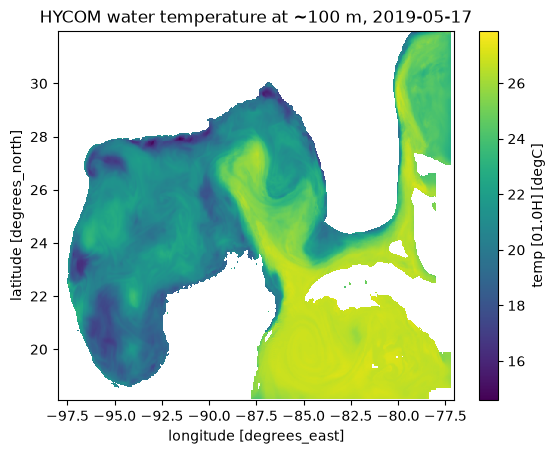

In [38]:
sst = sst_100m["water_temp"].isel(MT=0)
sst_mask = sst.where(temp_100m < 1e10)

sst_mask.plot()

plt.title("HYCOM water temperature at ~100 m, 2019-05-17")
plt.show()

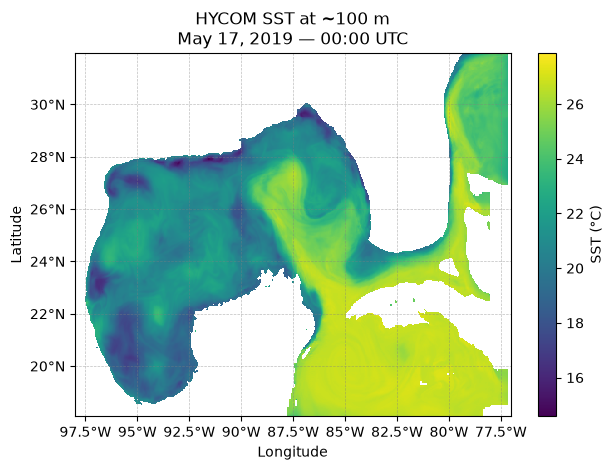

In [49]:
from matplotlib.ticker import FuncFormatter

# masking to avoid NAN values
sst = sst_100m["water_temp"].isel(MT=0)
sst_mask = sst.where(sst < 1e10)

fig, ax = plt.subplots()
sst_mask.plot(ax=ax, x="Longitude", y="Latitude", cbar_kwargs={"label": "SST (°C)"})

# formatting lat long labels
def longitude_label(value, position):
    lon = (value + 180) % 360 - 180
    direction = "W" if lon < 0 else "E"
    return f"{abs(lon):g}°{direction}"

def latitude_label(value, position):
    direction = "S" if value < 0 else "N"
    return f"{abs(value):g}°{direction}"

ax.xaxis.set_major_formatter(FuncFormatter(longitude_label))
ax.yaxis.set_major_formatter(FuncFormatter(latitude_label))

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("HYCOM SST at ~100 m\nMay 17, 2019 — 00:00 UTC")

ax.grid(True, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

**E.5** What is the SST for Flower Garden Banks national marine sanctuary on your birthday? Show your work

In [53]:
# representative location at East Flower Garden Bank
lat = 27.9095
lon = -93.5974

# checking the dataset's longitude convention
if float(sst_mask["Longitude"].max()) > 180:
    lon = lon % 360

# extracting temp at the nearest grid point
temp = sst_mask.sel(Latitude=lat, Longitude=lon, method="nearest")

# output
print("Selected latitude:", fgb_temp["Latitude"].item())
print("Selected longitude:", fgb_temp["Longitude"].item())
print(f"Temperature: {fgb_temp.item():.2f} °C")

Selected latitude: 27.906341552734375
Selected longitude: -93.5999984741211
Temperature: 19.71 °C
